In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [5]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [6]:
doubs_data.shape

(2679, 62)

In [7]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnies'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnies'].isna().sum()
print(f"Nombre de casernes sans id_compagnies : {none_count}")

print(caserne[['compagnie', 'id_compagnies']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnies : 0
         compagnie  id_compagnies
0         Besançon            1.0
1  Baume-les-Dames            2.0
2      Montbéliard            6.0
3       Pontarlier            4.0
4      Montbéliard            6.0


In [8]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnies'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnies'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnies'] = best_company_id

print(doubs_data[['hex_id', 'id_compagnies']].head())

            hex_id id_compagnies
0  871f820aaffffff           4.0
1  871f82d61ffffff          12.0
2  871f82d61ffffff          12.0
3  871f82d4dffffff           1.0
4  871f82700ffffff           5.0


In [9]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_data['id_caserne'] = None
doubs_data['distance'] = None

for idx, hexagone in doubs_data.iterrows():
    casernes_same_company = caserne[caserne['id_compagnies'] == hexagone['id_compagnies']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_data.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_data.at[idx, 'distance'] = distances.min()

print(doubs_data[['hex_id', 'id_compagnies', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnies id_caserne  distance
0  871f820aaffffff           4.0     840709       0.0
1  871f82d61ffffff          12.0     840704  0.005327
2  871f82d61ffffff          12.0     840704  0.005327
3  871f82d4dffffff           1.0     840698  0.039716
4  871f82700ffffff           5.0     840701  0.010387


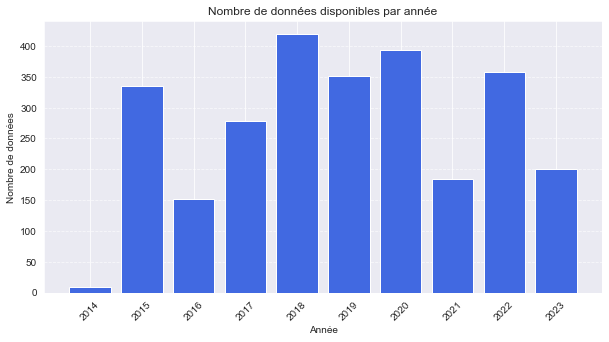

In [10]:
year_counts = doubs_data["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values, color="royalblue")
plt.xlabel("Année")
plt.ylabel("Nombre de données")
plt.title("Nombre de données disponibles par année")
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [11]:
print(year_counts)

2014.0      9
2015.0    335
2016.0    152
2017.0    278
2018.0    420
2019.0    351
2020.0    393
2021.0    184
2022.0    357
2023.0    200
Name: year, dtype: int64


In [12]:
doubs_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry', 'duree', 'centroid',
       'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'scale0',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'id_compagnies', 'id_caserne',
       'distance'],
      dtype='object')

In [13]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'year', 'scale0', 'hour', 'month', 'weekday', 'distance'
]

doubs_data = doubs_data.drop(columns=[col for col in cols_to_drop if col in doubs_data.columns])

In [14]:
doubs_data.columns

Index(['hex_id', 'date', 'duree_minutes', 'geometry', 'centroid',
       'centroid_lon', 'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'id_compagnies'],
      dtype='object')

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -193.308183   365.771043  35.301036  49.568009  0.030354   
1   2.1  -207.285164   379.748023  37.570279  50.756412  0.041264   
2   2.2  -221.262145   393.725004  37.570279  50.756412  0.041264   
3   2.3  -235.239125   407.701985  37.456715  51.824335  0.063704   
4   2.4  -249.216106   421.678965  38.777120  55.530498  0.042433   
5   2.5  -263.193087   435.655946  37.191344  54.357449  0.082462   
6   2.6  -277.170067   449.632927  37.416691  53.991449 -0.016037   
7   2.7  -291.147048   463.609907  36.014943  52.960120  0.022409   
8   2.8  -305.124029   477.586888  36.578454  55.067346  0.026893   
9   2.9  -319.101009   491.563869  36.578454  55.067346  0.026893   
10  3.0  -333.077990   505.540849  37.234171  57.746589  0.023126   
11  3.1  -347.054971   519.517830  36.426815  56.146294  0.076518   
12  3.2  -361.031951   533.494811  37.683943  57.799374  0.021339   
13  3.3  -375.008932   547.471791 

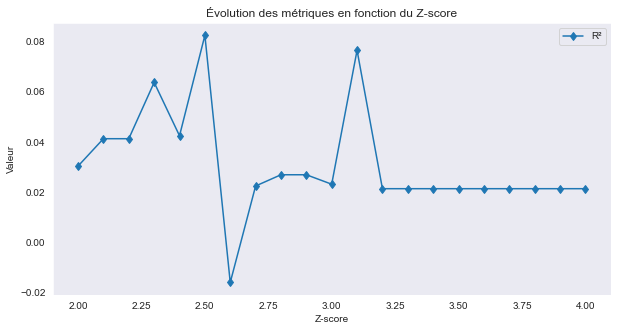

In [15]:
df = doubs_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

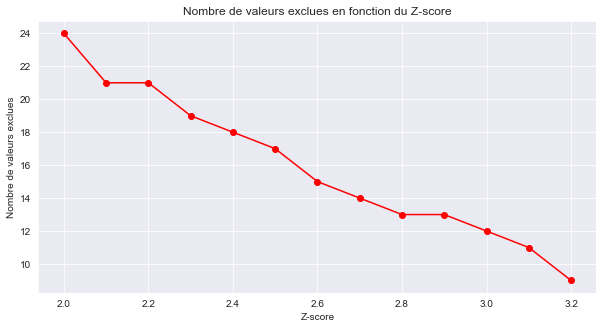

In [16]:
df = doubs_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

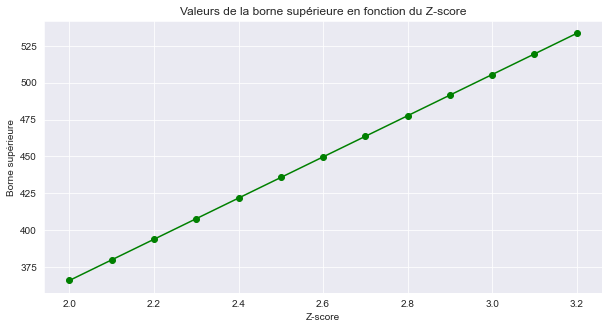

In [17]:
df = doubs_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [18]:
top_35_values = df['duree_minutes'].nlargest(35)

print(top_35_values)

1716    3885.850000
1199    3025.100000
1263    2753.933333
954     1725.383333
234     1667.683333
836     1629.883333
228     1625.983333
363     1500.500000
1112     920.333333
1341     531.866667
2583     530.733333
2590     510.183333
2853     504.333333
242      466.100000
2553     458.316667
160      443.816667
1931     437.516667
1173     435.516667
199      414.416667
2663     402.866667
505      398.400000
1804     373.866667
2419     371.916667
68       367.333333
1772     363.283333
260      359.183333
2778     358.000000
2767     357.716667
2816     355.216667
656      347.350000
0        345.533333
362      344.300000
937      342.533333
2297     331.250000
1009     326.916667
Name: duree_minutes, dtype: float64


In [19]:
doubs_data['z_score'] = np.abs(zscore(doubs_data['duree_minutes']))

doubs_data_filtered = doubs_data[doubs_data['z_score'] <= 2.9].drop(columns=['z_score'])

values_removed = len(doubs_data) - len(doubs_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(doubs_data) * 100:.2f}%")

Nombre de valeurs supprimées : 13
Pourcentage des données supprimées : 0.49%


In [20]:
doubs_data_filtered.columns

Index(['hex_id', 'date', 'duree_minutes', 'geometry', 'centroid',
       'centroid_lon', 'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'id_compagnies'],
      dtype='object')

In [21]:
def get_saison_annee(date):
    mois = date.month
    annee = date.year

    if mois in [12, 1, 2]:
        saison = "hiver"
        annee = annee if mois != 12 else annee + 1
    elif mois in [3, 4, 5]:
        saison = "printemps"
    elif mois in [6, 7, 8]:
        saison = "été"
    else:
        saison = "automne"

    return f"{saison} {annee}"

doubs_data_filtered["date"] = pd.to_datetime(doubs_data_filtered["date"])
doubs_data_filtered["saison_annee"] = doubs_data_filtered["date"].apply(get_saison_annee)

moyennes_saison_hex = (
    doubs_data_filtered.groupby(["hex_id", "saison_annee"])
    .agg({**{col: "mean" for col in doubs_data_filtered.select_dtypes(include="number").columns},
          "geometry": "first"})
    .reset_index()
)

print(moyennes_saison_hex.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff  printemps 2019     163.133333      6.350198     47.477082   
1  871f80492ffffff  printemps 2022      61.850000      6.350198     47.477082   
2  871f80492ffffff  printemps 2023      72.083333      6.350198     47.477082   
3  871f80492ffffff        été 2015      40.850000      6.350198     47.477082   
4  871f80492ffffff        été 2017     197.783333      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...     water       tree  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   

       grass     crops     shrub

In [22]:
moyennes_saison_hex = gpd.GeoDataFrame(moyennes_saison_hex, geometry="geometry")

In [23]:
def assign_compagnie(df, compagnies):
    df['id_compagnies'] = None

    for idx, row in df.iterrows():
        hex_geom = row['geometry']
        best_compagnie = None
        max_area = 0

        for _, compagnie_row in compagnies.iterrows():
            comp_geom = compagnie_row['geometry']

            if hex_geom.intersects(comp_geom):
                intersection = hex_geom.intersection(comp_geom)
                intersection_area = intersection.area

                if intersection_area > max_area:
                    best_compagnie = compagnie_row['id']
                    max_area = intersection_area

        if best_compagnie is not None:
            df.at[idx, 'id_compagnies'] = best_compagnie

    return df

moyennes_saison_hex = assign_compagnie(moyennes_saison_hex, compagnies)

In [24]:
compagnies.columns

Index(['id', 'nom', 'num', 'geometry'], dtype='object')

In [25]:
hexagones_uniques = moyennes_saison_hex["hex_id"].unique()

np.random.seed(42)
hex_train = np.random.choice(hexagones_uniques, size=int(0.7 * len(hexagones_uniques)), replace=False)

doubs_train = moyennes_saison_hex[moyennes_saison_hex["hex_id"].isin(hex_train)]
doubs_test = moyennes_saison_hex[~moyennes_saison_hex["hex_id"].isin(hex_train)]

print(f"Taille du train : {len(doubs_train)}, Taille du test : {len(doubs_test)}")

Taille du train : 1358, Taille du test : 643


In [26]:
def saison_to_index(saison_annee):
    saison, annee = saison_annee.split()
    annee = int(annee)
    saison_dict = {"hiver": 0.0, "printemps": 0.25, "été": 0.5, "automne": 0.75}
    return annee + saison_dict[saison]

In [27]:
map_doubs = moyennes_saison_hex[['hex_id', 'geometry']].drop_duplicates(subset="hex_id").copy()

print(map_doubs.head())
print(f"Nombre d'hexagones uniques : {len(map_doubs)}")

             hex_id                                           geometry
0   871f80492ffffff  POLYGON ((6.33348 47.48111, 6.33537 47.46913, ...
6   871f80493ffffff  POLYGON ((6.36503 47.48503, 6.36691 47.47305, ...
8   871f80498ffffff  POLYGON ((6.42815 47.49284, 6.43003 47.48086, ...
9   871f8049affffff  POLYGON ((6.41518 47.47292, 6.41706 47.46094, ...
10  871f8049cffffff  POLYGON ((6.40954 47.50886, 6.41142 47.49688, ...
Nombre d'hexagones uniques : 627


In [28]:
if map_doubs.crs is None:
    map_doubs.set_crs("EPSG:4326", allow_override=True, inplace=True)
else:
    print(f"CRS actuel: {map_doubs.crs}")

map_doubs_utm = map_doubs.to_crs(epsg=32632)

if doubs_train.crs is None:
    doubs_train.set_crs(epsg=4326, inplace=True)

doubs_train_utm = doubs_train.to_crs(epsg=32632)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


No handles with labels found to put in legend.


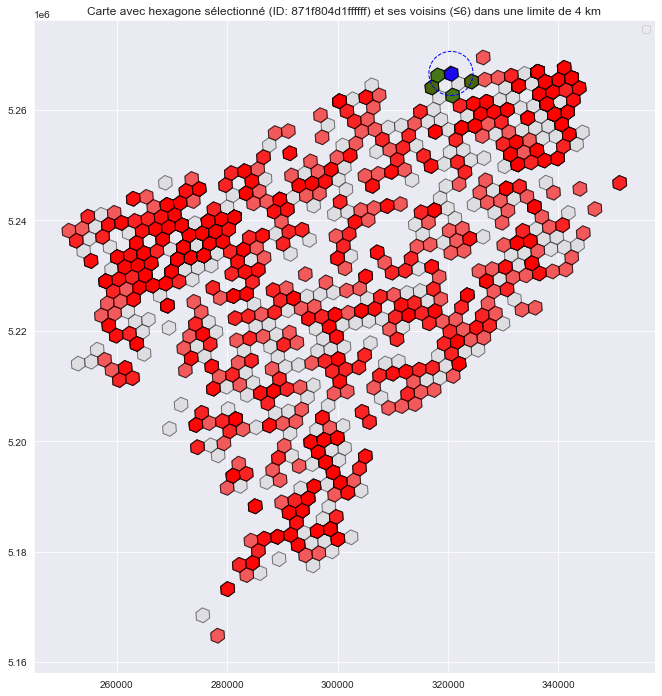

        Type           hex_id
15    Voisin  871f804d0ffffff
19    Voisin  871f804d8ffffff
1437  Voisin  871f82b2dffffff
17    Voisin  871f804d2ffffff


In [29]:
if doubs_train.crs is None:
    doubs_train.set_crs(epsg=4326, inplace=True)

if map_doubs.crs is None:
    map_doubs.set_crs(epsg=4326, inplace=True)

map_doubs_utm = map_doubs.to_crs(epsg=32632)
doubs_train_utm = doubs_train.to_crs(epsg=32632)

hex_random = map_doubs_utm.sample(1)

centroid_random = hex_random.geometry.centroid.iloc[0]

distance_km = 4000
buffer_4km = centroid_random.buffer(distance_km)

voisins_4km = map_doubs_utm[map_doubs_utm.geometry.intersects(buffer_4km)]

voisins_4km = voisins_4km[voisins_4km["hex_id"] != hex_random["hex_id"].iloc[0]]

voisins_4km = voisins_4km[voisins_4km["hex_id"].isin(doubs_train_utm["hex_id"])]

voisins_4km["distance"] = voisins_4km.geometry.centroid.distance(centroid_random)
voisins_4km = voisins_4km.nsmallest(6, "distance")

fig, ax = plt.subplots(figsize=(12, 12))

map_doubs_utm.plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5)

doubs_train_utm.plot(ax=ax, color="red", edgecolor="black", alpha=0.6, label="Hexagones de doubs_train")

x, y = centroid_random.x, centroid_random.y
circle = plt.Circle((x, y), distance_km, color="blue", fill=False, linestyle='--', label="Limite de 4 km")
ax.add_artist(circle)

voisins_4km.plot(ax=ax, color="green", edgecolor="black", alpha=0.7)

hex_random.plot(ax=ax, color="blue", edgecolor="black", alpha=0.9)

hex_id_random = hex_random["hex_id"].iloc[0]
plt.title(f"Carte avec hexagone sélectionné (ID: {hex_id_random}) et ses voisins (≤6) dans une limite de 4 km")

plt.legend(loc="upper right")
plt.show()

voisins_4km.insert(0, "Type", ["Voisin"] * len(voisins_4km))
voisins_4km_unique = voisins_4km.drop_duplicates(subset="hex_id")
print(voisins_4km_unique[["Type", "hex_id"]])

In [30]:
if doubs_train.crs is None:
    doubs_train.set_crs(epsg=4326, inplace=True)
if doubs_test.crs is None:
    doubs_test.set_crs(epsg=4326, inplace=True)
if map_doubs.crs is None:
    map_doubs.set_crs(epsg=4326, inplace=True)

doubs_train_utm = doubs_train.to_crs(epsg=32632)
doubs_test_utm = doubs_test.to_crs(epsg=32632)

buffer_distance = 4000
max_neighbors = 6

def get_neighbors(hex_row, train_gdf, buffer_distance=4000, max_neighbors=6):
    centroid = hex_row.geometry.centroid
    buffer_geom = centroid.buffer(buffer_distance)

    candidates = train_gdf[train_gdf.geometry.intersects(buffer_geom)]

    candidates = candidates[candidates["hex_id"] != hex_row["hex_id"]]

    if candidates.empty:
        return []

    candidates = candidates.copy()
    candidates["distance"] = candidates.geometry.centroid.distance(centroid)

    selected = candidates.nsmallest(max_neighbors, "distance")

    return selected["hex_id"].tolist()

doubs_train_utm["neighbors"] = doubs_train_utm.apply(lambda row: get_neighbors(row, doubs_train_utm, buffer_distance, max_neighbors), axis=1)

doubs_test_utm["neighbors"] = doubs_test_utm.apply(lambda row: get_neighbors(row, doubs_train_utm, buffer_distance, max_neighbors), axis=1)

print("Exemple dans doubs_train_utm:")
print(doubs_train_utm[["hex_id", "neighbors"]].head())

print("\nExemple dans doubs_test_utm:")
print(doubs_test_utm[["hex_id", "neighbors"]].head())


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Exemple dans doubs_train_utm:
            hex_id                                          neighbors
0  871f80492ffffff  [871f8286cffffff, 871f8286cffffff, 871f82860ff...
1  871f80492ffffff  [871f8286cffffff, 871f8286cffffff, 871f82860ff...
2  871f80492ffffff  [871f8286cffffff, 871f8286cffffff, 871f82860ff...
3  871f80492ffffff  [871f8286cffffff, 871f8286cffffff, 871f82860ff...
4  871f80492ffffff  [871f8286cffffff, 871f8286cffffff, 871f82860ff...

Exemple dans doubs_test_utm:
             hex_id                                          neighbors
6   871f80493ffffff  [871f80492ffffff, 871f80492ffffff, 871f80492ff...
7   871f80493ffffff  [871f80492ffffff, 871f80492ffffff, 871f80492ff...
10  871f8049cffffff  [871f80498ffffff, 871f8049effffff, 871f8049eff...
22  871f804deffffff  [871f804d1ffffff, 871f804d8ffffff, 871f804d8ff...
23  871f80690ffffff  [871f80696ffffff, 871f80696ffffff, 871f80696ff...


In [31]:
doubs_test_utm.columns

Index(['hex_id', 'saison_annee', 'duree_minutes', 'centroid_lon',
       'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'geometry',
       'id_compagnies', 'neighbors'],
      dtype='object')

In [32]:
def count_neighbors_distribution(df):
    counts = df["neighbors"].apply(len).value_counts().sort_index()
    return counts.to_dict()

train_neighbors_dist = count_neighbors_distribution(doubs_train_utm)
test_neighbors_dist = count_neighbors_distribution(doubs_test_utm)

print("Répartition des voisins dans doubs_train_utm :")
for k, v in train_neighbors_dist.items():
    print(f"{k} : {v}")

print("\nRépartition des voisins dans doubs_test_utm :")
for k, v in test_neighbors_dist.items():
    print(f"{k} : {v}")

Répartition des voisins dans doubs_train_utm :
0 : 3
1 : 5
2 : 2
3 : 12
4 : 20
5 : 15
6 : 1301

Répartition des voisins dans doubs_test_utm :
1 : 4
2 : 10
4 : 1
5 : 2
6 : 626


In [33]:
def compute_neighbors_stats(df, train_df):
    stats = ["mean", "median", "min", "max", "std", "q1", "q3"]
    results = {stat: [] for stat in stats}

    for index, row in df.iterrows():
        current_season = row["saison_annee"]
        current_hex_id = row["hex_id"]
        historical_hexagons = train_df[train_df["hex_id"] == current_hex_id]

        neighbors = row["neighbors"]
        neighbors_data = train_df[train_df["hex_id"].isin(neighbors)]
        valid_neighbors = neighbors_data[neighbors_data["saison_annee"] < current_season]
        relevant_data = pd.concat([valid_neighbors, historical_hexagons])
        duree_values = relevant_data["duree_minutes"]

        results["mean"].append(duree_values.mean() if not duree_values.empty else np.nan)
        results["median"].append(duree_values.median() if not duree_values.empty else np.nan)
        results["min"].append(duree_values.min() if not duree_values.empty else np.nan)
        results["max"].append(duree_values.max() if not duree_values.empty else np.nan)
        results["std"].append(duree_values.std() if not duree_values.empty else np.nan)
        results["q1"].append(duree_values.quantile(0.25) if not duree_values.empty else np.nan)
        results["q3"].append(duree_values.quantile(0.75) if not duree_values.empty else np.nan)

    for stat in stats:
        df[f"neighbors_{stat}"] = results[stat]

compute_neighbors_stats(doubs_train_utm, doubs_train_utm)
compute_neighbors_stats(doubs_test_utm, doubs_train_utm)

In [34]:
doubs_test_utm.columns

Index(['hex_id', 'saison_annee', 'duree_minutes', 'centroid_lon',
       'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'geometry',
       'id_compagnies', 'neighbors', 'neighbors_mean', 'neighbors_median',
       'neighbors_min', 'neighbors_max', 'neighbors_std', 'neighbors_q1',
       'neighbors_q3'],
      dtype='object')

In [35]:
def calculer_statistiques_par_compagnie(df):
    stats_df = df.groupby('id_compagnies')['duree_minutes'].agg(
        mean='mean',
        std='std',
        median='median',
        min='min',
        max='max',
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    ).reset_index()

    return stats_df

compagnies_stats = calculer_statistiques_par_compagnie(doubs_train_utm)

In [36]:
compagnies_stats.columns

Index(['id_compagnies', 'mean', 'std', 'median', 'min', 'max', 'q1', 'q3'], dtype='object')

In [37]:
def fill_missing_with_companies_stats(df, compagnies_stats):
    stats = ['mean', 'std', 'median', 'min', 'max', 'q1', 'q3']

    for stat in stats:
        for i, row in df.iterrows():
            if pd.isna(row[f'neighbors_{stat}']):
                id_compagnie = row['id_compagnies']

                company_value = compagnies_stats.loc[compagnies_stats['id_compagnies'] == id_compagnie, stat].values

                if len(company_value) > 0:
                    df.at[i, f'neighbors_{stat}'] = company_value[0]

    return df

doubs_train_utm = fill_missing_with_companies_stats(doubs_train_utm, compagnies_stats)
doubs_test_utm = fill_missing_with_companies_stats(doubs_test_utm, compagnies_stats)

In [38]:
compagnies_stats_renamed = compagnies_stats.rename(columns={
    'mean': 'compagnies_mean',
    'std': 'compagnies_std',
    'median': 'compagnies_median',
    'min': 'compagnies_min',
    'max': 'compagnies_max',
    'q1': 'compagnies_q1',
    'q3': 'compagnies_q3'
})

doubs_train_utm = doubs_train_utm.merge(compagnies_stats_renamed[['id_compagnies', 'compagnies_mean', 'compagnies_std', 'compagnies_median', 'compagnies_min', 'compagnies_max', 'compagnies_q1', 'compagnies_q3']],
                                        on='id_compagnies', how='left')

doubs_test_utm = doubs_test_utm.merge(compagnies_stats_renamed[['id_compagnies', 'compagnies_mean', 'compagnies_std', 'compagnies_median', 'compagnies_min', 'compagnies_max', 'compagnies_q1', 'compagnies_q3']],
                                      on='id_compagnies', how='left')


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train = doubs_train_utm.drop(columns=["duree_minutes", "saison_annee", "hex_id", "neighbors", "id_compagnies", "geometry"])
y_train = doubs_train_utm["duree_minutes"]

X_test = doubs_test_utm.drop(columns=["duree_minutes", "saison_annee", "hex_id", "neighbors", "id_compagnies", "geometry"])
y_test = doubs_test_utm["duree_minutes"]

def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, rmse, r2

models = {
    "Régression Linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

for model_name, model in models.items():
    print(f"Évaluation du modèle : {model_name}")

    mae, mse, rmse, r2 = train_and_evaluate(model, X_train, y_train, X_test, y_test)

    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R² : {r2:.4f}")
    print("-" * 50)

Évaluation du modèle : Régression Linéaire
MAE : 40.5096
MSE : 3556.5282
RMSE : 59.6366
R² : -0.0535
--------------------------------------------------
Évaluation du modèle : Random Forest
MAE : 42.5865
MSE : 3712.6855
RMSE : 60.9318
R² : -0.0998
--------------------------------------------------
Évaluation du modèle : XGBoost
MAE : 42.7251
MSE : 3802.2820
RMSE : 61.6626
R² : -0.1263
--------------------------------------------------


In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                       param_grid=param_grid_rf,
                       cv=5,
                       n_jobs=-1,
                       scoring='r2')
grid_rf.fit(X_train, y_train)

print(f"Meilleurs paramètres pour Random Forest : {grid_rf.best_params_}")
print(f"Meilleur score (neg_mean_squared_error) : {grid_rf.best_score_}")

Meilleurs paramètres pour Random Forest : {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Meilleur score (neg_mean_squared_error) : 0.2383369483139719


In [41]:
"""Meilleurs paramètres pour Random Forest : {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Meilleur score (neg_mean_squared_error) : 0.2383369483139719"""

"Meilleurs paramètres pour Random Forest : {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}\nMeilleur score (neg_mean_squared_error) : 0.2380691904556212"

In [ ]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid_xgb = GridSearchCV(estimator=XGBRegressor(random_state=42),
                        param_grid=param_grid_xgb,
                        cv=5,
                        n_jobs=-1,
                        scoring='r2')
grid_xgb.fit(X_train, y_train)

print(f"Meilleurs paramètres pour XGBoost : {grid_xgb.best_params_}")
print(f"Meilleur score (R2) : {grid_xgb.best_score_}")

In [43]:
"""Meilleurs paramètres pour XGBoost : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Meilleur score (R2) : 0.2442331749960208"""

"Meilleurs paramètres pour XGBoost : {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}\nMeilleur score (neg_mean_squared_error) : 0.24639368500038278"

In [44]:
rf_model = RandomForestRegressor(
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=100,
    random_state=42
)

xgb_model = XGBRegressor(
    colsample_bytree=0.7,
    learning_rate=0.01,
    max_depth=3,
    n_estimators=300,
    subsample=0.7,
    random_state=42
)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

def eval_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"🔹 Évaluation du modèle : {name}")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R² : {r2:.4f}")
    print("-" * 50)

eval_model("Random Forest", y_test, rf_pred)
eval_model("XGBoost", y_test, xgb_pred)

🔹 Évaluation du modèle : Random Forest
MAE : 41.2423
MSE : 3644.5418
RMSE : 60.3700
R² : -0.0796
--------------------------------------------------
🔹 Évaluation du modèle : XGBoost
MAE : 39.8145
MSE : 3450.7976
RMSE : 58.7435
R² : -0.0222
--------------------------------------------------


In [45]:
from sklearn.model_selection import cross_val_score
import numpy as np

rf_model = RandomForestRegressor(
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=100,
    random_state=42
)

cv_folds = 5

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv_folds, scoring='r2', n_jobs=-1)

print(f"Scores R² pour chaque fold : {cv_scores}")
print(f"Score R² moyen : {np.mean(cv_scores):.4f}")
print(f"Écart-type des scores : {np.std(cv_scores):.4f}")

Scores R² pour chaque fold : [0.28566134 0.16597274 0.14962149 0.26824767 0.31562795]
Score R² moyen : 0.2370
Écart-type des scores : 0.0666


In [46]:
scaler = StandardScaler()
features = [col for col in X_train.columns if col != "duree_minutes"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features] = scaler.fit_transform(X_train[features])
X_test_scaled[features] = scaler.transform(X_test[features])

ridge = Ridge(alpha=1.0)
rf_model = RandomForestRegressor(
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=100,
    random_state=42
)
xgb_model = XGBRegressor(
    colsample_bytree=0.7,
    learning_rate=0.01,
    max_depth=3,
    n_estimators=300,
    subsample=0.7,
    random_state=42
)

ridge.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)
rf_pred_scaled = rf_model.predict(X_test_scaled)
xgb_pred_scaled = xgb_model.predict(X_test_scaled)

def eval_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"🔹 Évaluation du modèle : {name}")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R² : {r2:.4f}")
    print("-" * 50)

eval_model("Ridge Regression", y_test, ridge_pred)
eval_model("Random Forest (Normalisé)", y_test, rf_pred_scaled)
eval_model("XGBoost (Normalisé)", y_test, xgb_pred_scaled)

🔹 Évaluation du modèle : Ridge Regression
MAE : 39.9362
MSE : 3495.6830
RMSE : 59.1243
R² : -0.0355
--------------------------------------------------
🔹 Évaluation du modèle : Random Forest (Normalisé)
MAE : 41.2678
MSE : 3647.3524
RMSE : 60.3933
R² : -0.0804
--------------------------------------------------
🔹 Évaluation du modèle : XGBoost (Normalisé)
MAE : 39.8083
MSE : 3448.4233
RMSE : 58.7233
R² : -0.0215
--------------------------------------------------


In [47]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
    }
    model = RandomForestRegressor(**params, random_state=42)
    model.fit(X_train_sub, y_train_sub)
    preds = model.predict(X_val)
    return r2_score(y_val, preds)

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=30)

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    model = XGBRegressor(**params, random_state=42)
    model.fit(X_train_sub, y_train_sub)
    preds = model.predict(X_val)
    return r2_score(y_val, preds)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=30)

print("Meilleurs paramètres pour Random Forest:", study_rf.best_params)
print("Meilleur R² pour Random Forest:", study_rf.best_value)

print("Meilleurs paramètres pour XGBoost:", study_xgb.best_params)
print("Meilleur R² pour XGBoost:", study_xgb.best_value)

[I 2025-02-26 11:07:31,434] A new study created in memory with name: no-name-98d1581c-40dc-41c7-9749-ac3dcf371964
[I 2025-02-26 11:07:36,577] Trial 0 finished with value: 0.25113694631773864 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.25113694631773864.
[I 2025-02-26 11:07:39,319] Trial 1 finished with value: 0.25748900593408786 and parameters: {'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 11, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.25748900593408786.
[I 2025-02-26 11:07:41,796] Trial 2 finished with value: 0.2609980723559908 and parameters: {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 15, 'min_samples_leaf': 8}. Best is trial 2 with value: 0.2609980723559908.
[I 2025-02-26 11:07:47,943] Trial 3 finished with value: 0.24722700904508244 and parameters: {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 18, 'min_samples_leaf': 9}. Best is trial 2 with 

Meilleurs paramètres pour Random Forest: {'n_estimators': 150, 'max_depth': 4, 'min_samples_split': 18, 'min_samples_leaf': 9}
Meilleur R² pour Random Forest: 0.2833136323103763
Meilleurs paramètres pour XGBoost: {'n_estimators': 150, 'learning_rate': 0.010243954447425466, 'max_depth': 5, 'subsample': 0.575084908803001, 'colsample_bytree': 0.8013406023537935}
Meilleur R² pour XGBoost: 0.2443776259117948


In [48]:
rf_model_optimized = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_split=12,
    min_samples_leaf=8,
    random_state=42
)

xgb_model_optimized = XGBRegressor(
    n_estimators=150,
    learning_rate=0.011079350969673135,
    max_depth=6,
    subsample=0.6182001662267541,
    colsample_bytree=0.6955560439860944,
    random_state=42
)

rf_model_optimized.fit(X_train, y_train)
xgb_model_optimized.fit(X_train, y_train)

rf_pred_optimized = rf_model_optimized.predict(X_test)
xgb_pred_optimized = xgb_model_optimized.predict(X_test)

def eval_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"🔹 Évaluation du modèle : {name}")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R² : {r2:.4f}")
    print("-" * 50)

eval_model("Random Forest (Optimisé)", y_test, rf_pred_optimized)
eval_model("XGBoost (Optimisé)", y_test, xgb_pred_optimized)

🔹 Évaluation du modèle : Random Forest (Optimisé)
MAE : 40.5068
MSE : 3565.3352
RMSE : 59.7104
R² : -0.0561
--------------------------------------------------
🔹 Évaluation du modèle : XGBoost (Optimisé)
MAE : 39.4345
MSE : 3336.6447
RMSE : 57.7637
R² : 0.0116
--------------------------------------------------
